In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Make plots look clean
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")

# Show all columns when printing dataframes
pd.set_option("display.max_columns", 50)

print("All imports successful")

All imports successful


In [8]:
import os
os.chdir(r"C:\Users\User\OneDrive\Desktop\projects\pulsechurn")

df = pd.read_csv("data/processed/churn_clean.csv")

print(f"Shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nFirst 5 rows:")
df.head()

Shape: (7043, 20)

Column names:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

First 5 rows:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [9]:
print("=== Numeric columns summary ===")
df.describe()

=== Numeric columns summary ===


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7043.000000,7043.000000,7043.000000,7032.000000,7043.000000
mean,0.162147,32.371149,64.761692,2283.300441,0.265370
std,0.368612,24.559481,30.090047,2266.771362,0.441561
min,0.000000,0.000000,18.250000,18.800000,0.000000
25%,0.000000,9.000000,35.500000,401.450000,0.000000
50%,0.000000,29.000000,70.350000,1397.475000,0.000000
75%,0.000000,55.000000,89.850000,3794.737500,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


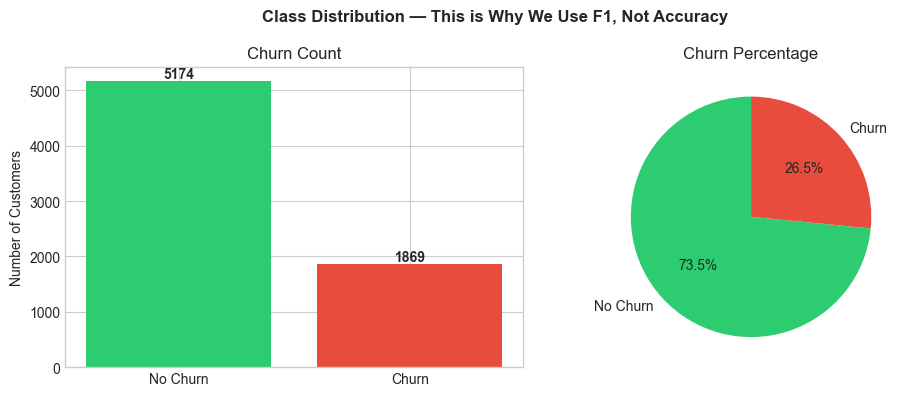

Plot saved to reports/figures/


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Count plot
churn_counts = df["Churn"].value_counts()
axes[0].bar(["No Churn", "Churn"], churn_counts.values, color=["#2ecc71", "#e74c3c"])
axes[0].set_title("Churn Count")
axes[0].set_ylabel("Number of Customers")
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha="center", fontweight="bold")

# Percentage plot
axes[1].pie(
    churn_counts.values,
    labels=["No Churn", "Churn"],
    autopct="%1.1f%%",
    colors=["#2ecc71", "#e74c3c"],
    startangle=90
)
axes[1].set_title("Churn Percentage")

plt.suptitle("Class Distribution — This is Why We Use F1, Not Accuracy", 
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("reports/figures/01_churn_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to reports/figures/")

## Finding 1 — Class Imbalance

The dataset is imbalanced: 73.5% of customers did NOT churn, only 26.5% did.

This means a naive model that predicts "No Churn" for every customer would 
achieve 73.5% accuracy while being completely useless for the business.

**Decision:** We will use F1-score and AUC-PR as our evaluation metrics, 
not accuracy. We will also use `scale_pos_weight` in XGBoost to penalize 
misclassifying the minority (churn) class.

c:\Users\User\OneDrive\Desktop\projects\pulsechurn\venv\Lib\site-packages\missingno\missingno.py:61: UserWarning: Plotting a sparkline on an existing axis is not currently supported. To remove this warning, set sparkline=False.
  warnings.warn(


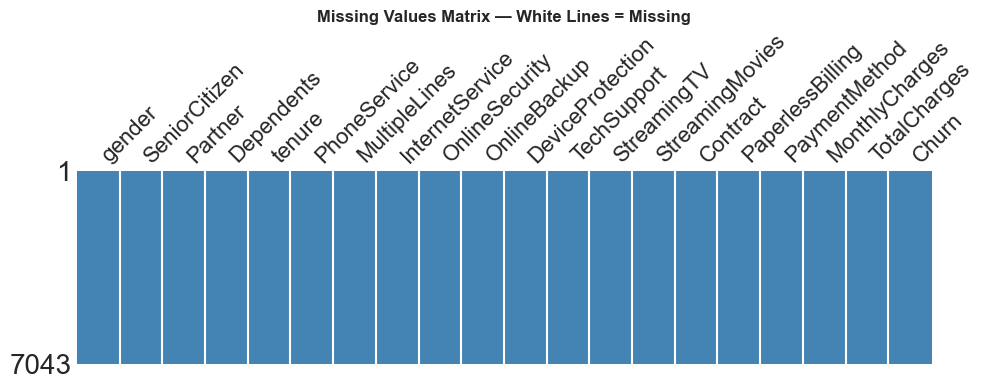


Missing value counts:
TotalCharges    11
dtype: int64


In [14]:
fig, ax = plt.subplots(figsize=(10, 4))
msno.matrix(df, ax=ax, color=(0.27, 0.52, 0.71))
plt.title("Missing Values Matrix — White Lines = Missing", fontweight="bold")
plt.tight_layout()
plt.savefig("reports/figures/02_missing_values.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nMissing value counts:")
print(df.isnull().sum()[df.isnull().sum() > 0])

## Finding 2 — Missing Values

Only `TotalCharges` has missing values — 11 rows out of 7043 (0.15%).

These are new customers with `tenure = 0` who haven't received a bill yet.
We will handle these with `SimpleImputer(strategy='median')` inside our 
sklearn Pipeline on Day 2. We do NOT drop these rows.

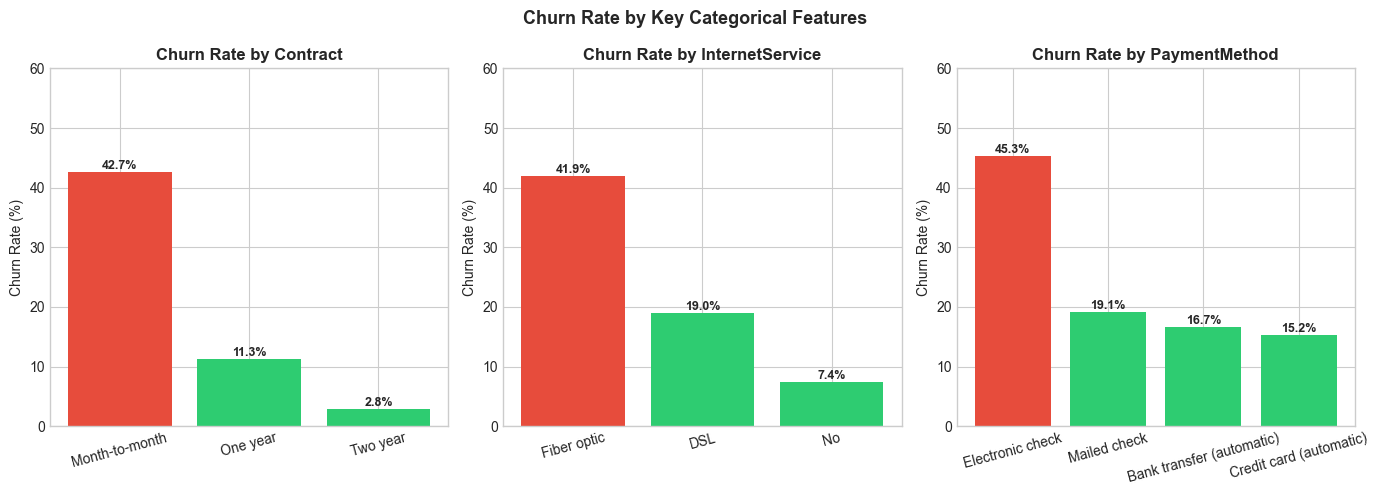

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

cat_cols = ["Contract", "InternetService", "PaymentMethod"]

for ax, col in zip(axes, cat_cols):
    churn_rate = df.groupby(col)["Churn"].mean().sort_values(ascending=False)
    bars = ax.bar(churn_rate.index, churn_rate.values * 100, 
                  color=["#e74c3c" if x > 0.3 else "#2ecc71" for x in churn_rate.values])
    ax.set_title(f"Churn Rate by {col}", fontweight="bold")
    ax.set_ylabel("Churn Rate (%)")
    ax.set_ylim(0, 60)
    for bar, val in zip(bars, churn_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{val*100:.1f}%", ha="center", fontsize=9, fontweight="bold")
    ax.tick_params(axis="x", rotation=15)

plt.suptitle("Churn Rate by Key Categorical Features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("reports/figures/03_churn_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

## Finding 3 — Contract Type is the Strongest Signal

Month-to-month customers churn at 42.7% vs 2.8% for two-year contracts — 
a 15x difference. This is the single strongest predictor we've found so far.

Fiber optic internet (41.9% churn) and electronic check payment (45.3% churn)
are also strong signals.

**Business implication:** Retention efforts should prioritize converting 
month-to-month customers to annual contracts.

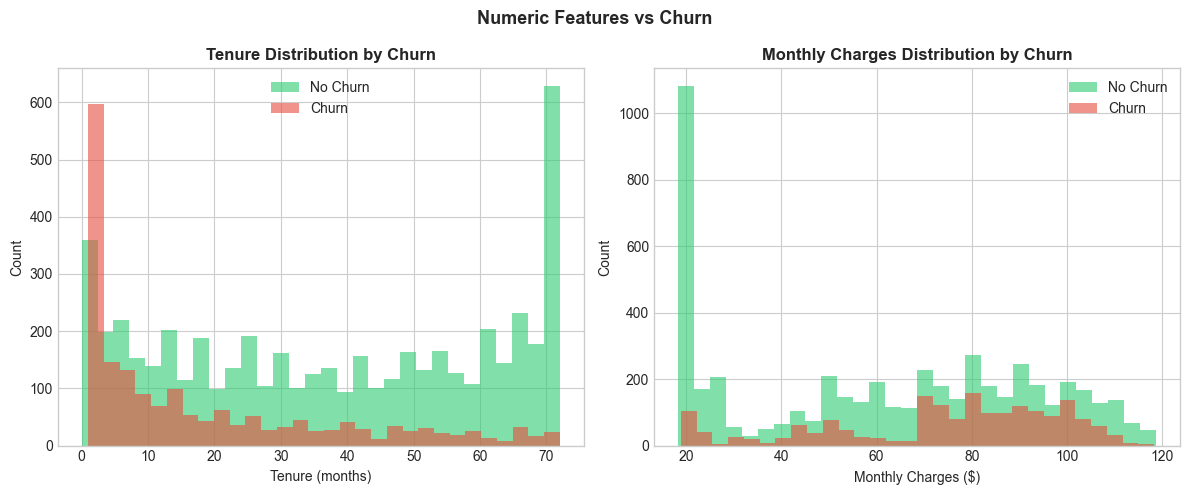

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Tenure distribution
for churn_val, label, color in [(0, "No Churn", "#2ecc71"), (1, "Churn", "#e74c3c")]:
    axes[0].hist(df[df["Churn"] == churn_val]["tenure"], 
                 bins=30, alpha=0.6, label=label, color=color)
axes[0].set_title("Tenure Distribution by Churn", fontweight="bold")
axes[0].set_xlabel("Tenure (months)")
axes[0].set_ylabel("Count")
axes[0].legend()

# MonthlyCharges distribution
for churn_val, label, color in [(0, "No Churn", "#2ecc71"), (1, "Churn", "#e74c3c")]:
    axes[1].hist(df[df["Churn"] == churn_val]["MonthlyCharges"],
                 bins=30, alpha=0.6, label=label, color=color)
axes[1].set_title("Monthly Charges Distribution by Churn", fontweight="bold")
axes[1].set_xlabel("Monthly Charges ($)")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.suptitle("Numeric Features vs Churn", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("reports/figures/04_numeric_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## Finding 4 — New Customers and High Payers Churn Most

**Tenure:** Churn is heavily concentrated in the first 1-5 months. 
Customers who survive past 12 months are very unlikely to churn.
Tenure is a strong negative predictor of churn.

**MonthlyCharges:** Higher-paying customers ($70-120/month) churn more 
than lower-paying ones. This likely overlaps with the Fiber optic and 
month-to-month contract segments we saw earlier.

**Decision:** Both `tenure` and `MonthlyCharges` will be scaled with 
`StandardScaler` in our pipeline since they have very different ranges.

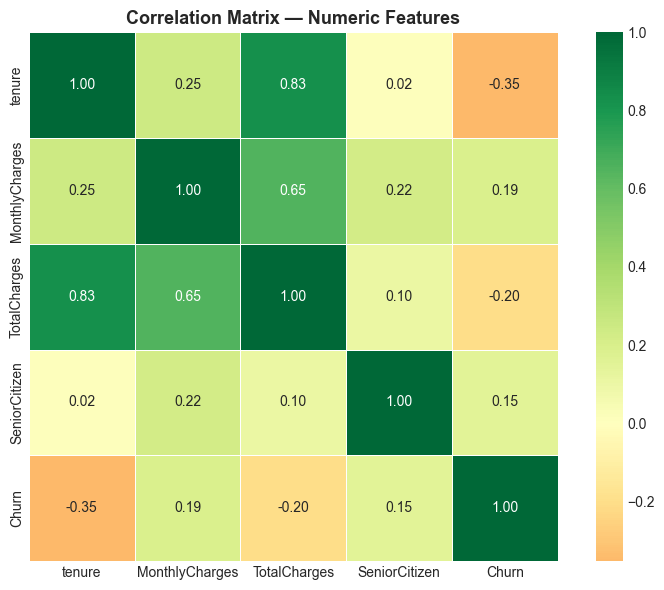

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))

numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges", 
                "SeniorCitizen", "Churn"]
corr_matrix = df[numeric_cols].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    square=True,
    ax=ax,
    linewidths=0.5
)

ax.set_title("Correlation Matrix — Numeric Features", 
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("reports/figures/05_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## Finding 5 — Tenure is the Strongest Numeric Predictor

`tenure` has the highest correlation with `Churn` at -0.35 (negative = 
longer tenure means less churn).

`TotalCharges` is highly correlated with `tenure` (0.83) — it's mostly 
redundant. We'll keep it in the model but expect SHAP to assign it low 
importance relative to tenure.

`MonthlyCharges` has a weak positive correlation (0.19) — higher bills 
slightly increase churn risk.

In [19]:
print("=" * 50)
print("EDA SUMMARY — KEY FINDINGS")
print("=" * 50)
print(f"\n Dataset: {df.shape[0]} customers, {df.shape[1]} features")
print(f"\n Churn rate: {df['Churn'].mean()*100:.1f}% (imbalanced)")
print(f"\n Missing values: TotalCharges only ({df['TotalCharges'].isna().sum()} rows)")
print(f"\n Top churn segments:")
print(f"   - Month-to-month contracts: {df[df['Contract']=='Month-to-month']['Churn'].mean()*100:.1f}%")
print(f"   - Fiber optic internet: {df[df['InternetService']=='Fiber optic']['Churn'].mean()*100:.1f}%")
print(f"   - Electronic check payment: {df[df['PaymentMethod']=='Electronic check']['Churn'].mean()*100:.1f}%")
print(f"   - Tenure < 6 months: {df[df['tenure']<6]['Churn'].mean()*100:.1f}%")
print(f"\n Strongest numeric predictor: tenure (corr={df['tenure'].corr(df['Churn']):.2f})")
print(f"\n Figures saved to reports/figures/")
print("\n" + "=" * 50)
print("READY FOR MODELING")
print("=" * 50)

EDA SUMMARY — KEY FINDINGS

 Dataset: 7043 customers, 20 features

 Churn rate: 26.5% (imbalanced)

 Missing values: TotalCharges only (11 rows)

 Top churn segments:
   - Month-to-month contracts: 42.7%
   - Fiber optic internet: 41.9%
   - Electronic check payment: 45.3%
   - Tenure < 6 months: 54.3%

 Strongest numeric predictor: tenure (corr=-0.35)

 Figures saved to reports/figures/

READY FOR MODELING
